In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import scipy.cluster.hierarchy as sch
import warnings

In [2]:
warnings.filterwarnings('ignore')


df = pd.read_csv("test.csv") 


if 'Activity' in df.columns:
    X = df.drop(columns=['Activity', 'subject'], errors='ignore')
    y_true_labels = df['Activity']
else:
    X = df.copy()
    y_true_labels = None
    print("No 'Activity' column found. External metrics (ARI, NMI) will be skipped.")

In [3]:
X = X.fillna(X.mean())


if y_true_labels is not None:
    encoder = LabelEncoder()
    y_true_encoded = encoder.fit_transform(y_true_labels)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Dataset shape after preprocessing: {X_scaled.shape}")

Dataset shape after preprocessing: (2947, 561)



Table 1: K-Means Elbow Method Results
|   Number of Clusters (k) |   WCSS (Inertia) |   Silhouette Score |
|-------------------------:|-----------------:|-------------------:|
|                        2 |           918351 |             0.3921 |
|                        3 |           814303 |             0.3039 |
|                        4 |           777281 |             0.1353 |
|                        5 |           750010 |             0.1079 |
|                        6 |           729516 |             0.103  |
|                        7 |           711693 |             0.105  |
|                        8 |           697957 |             0.1012 |


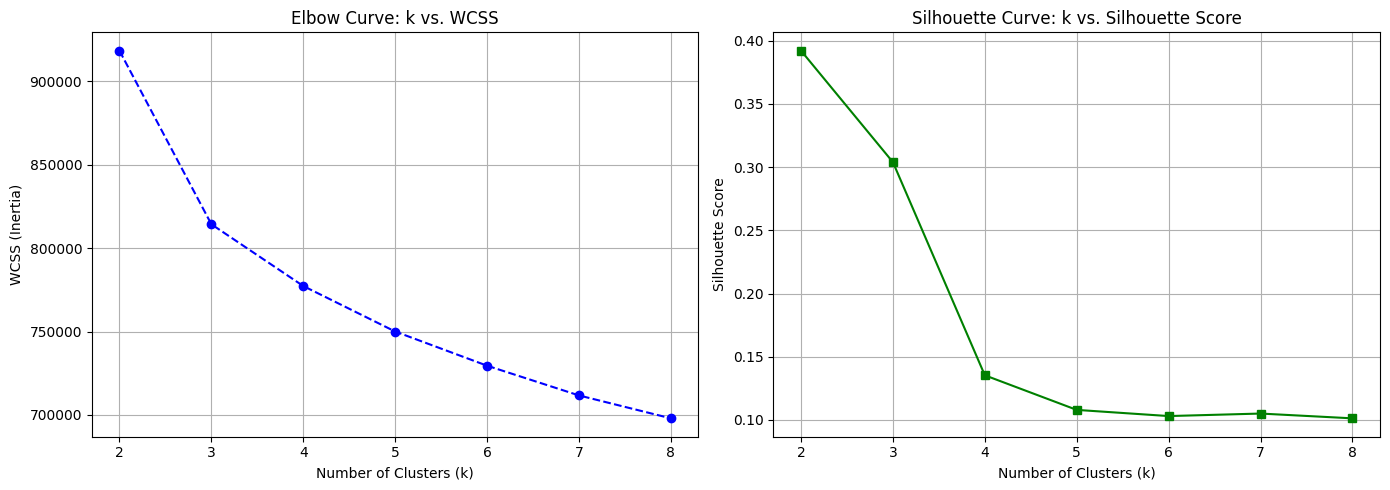

In [4]:
k_values = range(2, 9)
wcss_list = []
silhouette_list = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    wcss_list.append(kmeans.inertia_)
    silhouette_list.append(silhouette_score(X_scaled, cluster_labels))
table1_data = {
    "Number of Clusters (k)": k_values,
    "WCSS (Inertia)": [round(w, 2) for w in wcss_list],
    "Silhouette Score": [round(s, 4) for s in silhouette_list]
}
df_table1 = pd.DataFrame(table1_data)

print("\n" + "="*60)
print("Table 1: K-Means Elbow Method Results")
print("="*60)
print(df_table1.to_markdown(index=False))
fig, ax = plt.subplots(1, 2, figsize=(14, 5))


ax[0].plot(k_values, wcss_list, marker='o', linestyle='--', color='b')
ax[0].set_title('Elbow Curve: k vs. WCSS')
ax[0].set_xlabel('Number of Clusters (k)')
ax[0].set_ylabel('WCSS (Inertia)')
ax[0].grid(True)


ax[1].plot(k_values, silhouette_list, marker='s', linestyle='-', color='g')
ax[1].set_title('Silhouette Curve: k vs. Silhouette Score')
ax[1].set_xlabel('Number of Clusters (k)')
ax[1].set_ylabel('Silhouette Score')
ax[1].grid(True)

plt.tight_layout()
plt.show()    

In [5]:
optimal_k = 6 


kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)


dbscan = DBSCAN(eps=15.0, min_samples=10) 
dbscan_labels = dbscan.fit_predict(X_scaled)


hac = AgglomerativeClustering(n_clusters=optimal_k, metric='euclidean', linkage='ward')
hac_labels = hac.fit_predict(X_scaled)


model_labels = {
    "K-Means": kmeans_labels,
    "DBSCAN": dbscan_labels,
    "Hierarchical (Ward)": hac_labels
}

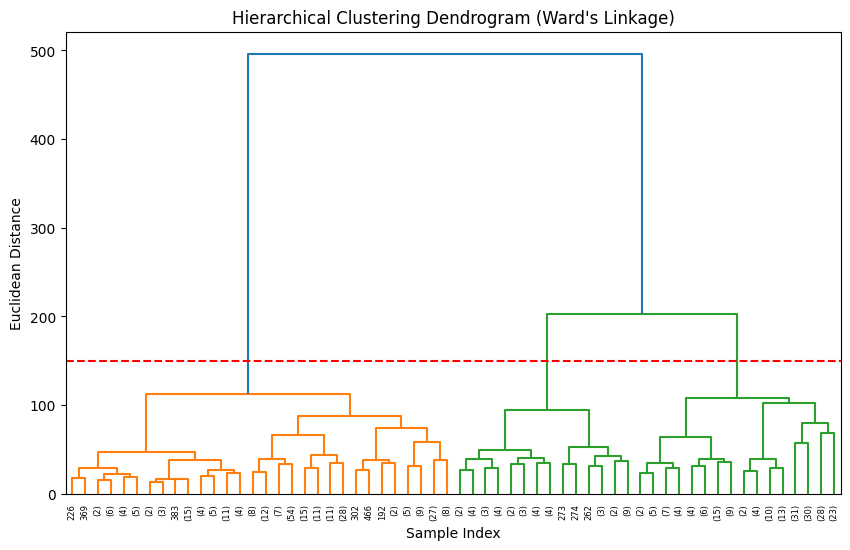

In [6]:
plt.figure(figsize=(10, 6))
plt.title("Hierarchical Clustering Dendrogram (Ward's Linkage)")
plt.xlabel("Sample Index")
plt.ylabel("Euclidean Distance")


subset_X = X_scaled[:500] 
Z = sch.linkage(subset_X, method='ward')

sch.dendrogram(Z, truncate_mode='level', p=5)
plt.axhline(y=150, color='r', linestyle='--') 
plt.show()

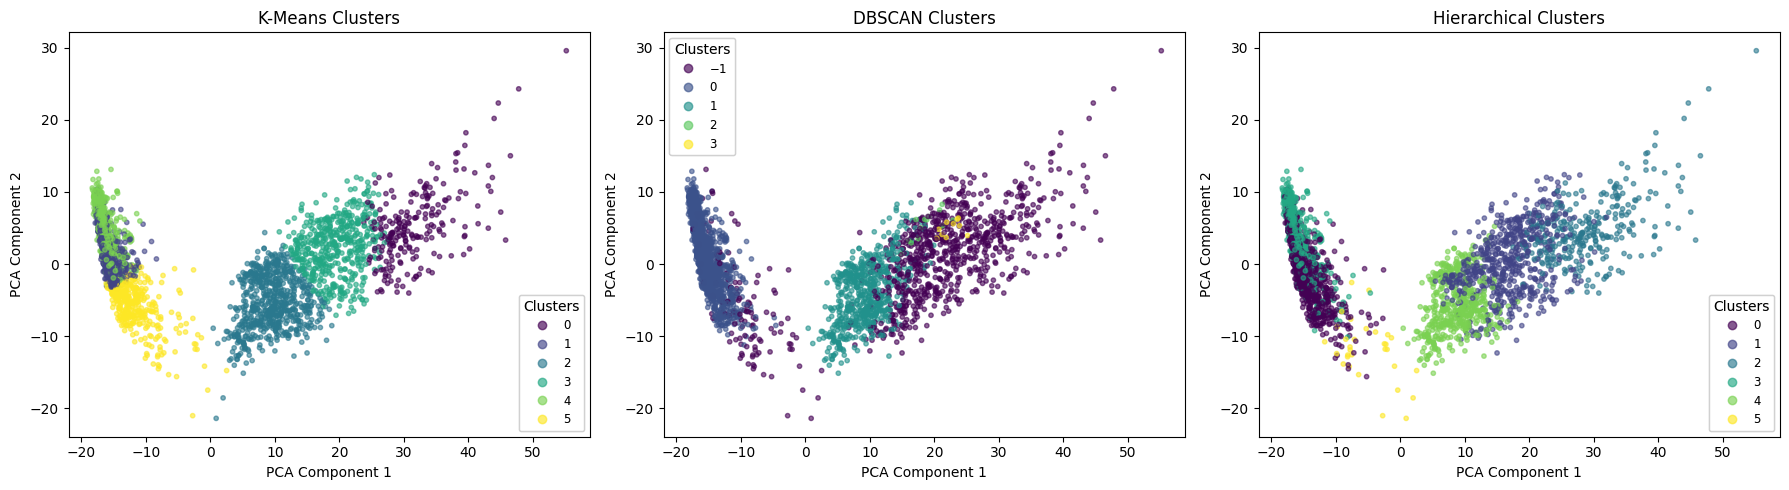

In [7]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ["K-Means Clusters", "DBSCAN Clusters", "Hierarchical Clusters"]
labels_list = [kmeans_labels, dbscan_labels, hac_labels]

for i, ax in enumerate(axes):
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_list[i], cmap='viridis', s=10, alpha=0.6)
    ax.set_title(titles[i])
    ax.set_xlabel("PCA Component 1")
    ax.set_ylabel("PCA Component 2")
   
    legend1 = ax.legend(*scatter.legend_elements(), title="Clusters", loc="best", fontsize='small')
    ax.add_artist(legend1)

plt.tight_layout()
plt.show()

In [8]:
results = []

for name, labels in model_labels.items():

    if len(set(labels)) > 1:
        sil = silhouette_score(X_scaled, labels)
        db = davies_bouldin_score(X_scaled, labels)
        ch = calinski_harabasz_score(X_scaled, labels)
        

        ari = adjusted_rand_score(y_true_encoded, labels) if y_true_labels is not None else None
        nmi = normalized_mutual_info_score(y_true_encoded, labels) if y_true_labels is not None else None
    else:
        sil, db, ch, ari, nmi = [0]*5
        
    results.append({
        "Algorithm": name,
        "Silhouette": sil,
        "Davies-Bouldin": db,
        "Calinski-Harabasz": ch,
        "ARI": ari,
        "NMI": nmi
    })

df_metrics = pd.DataFrame(results)

In [9]:
print("\n" + "="*80)
print("Clustering Evaluation Metrics")
print("="*80)
print(df_metrics.to_markdown(index=False))


Clustering Evaluation Metrics
| Algorithm           |   Silhouette |   Davies-Bouldin |   Calinski-Harabasz |      ARI |      NMI |
|:--------------------|-------------:|-----------------:|--------------------:|---------:|---------:|
| K-Means             |    0.103044  |          2.65954 |             744.809 | 0.434384 | 0.573538 |
| DBSCAN              |    0.186474  |          2.48658 |             563.785 | 0.290353 | 0.436187 |
| Hierarchical (Ward) |    0.0970216 |          2.58563 |             705.173 | 0.521685 | 0.641734 |


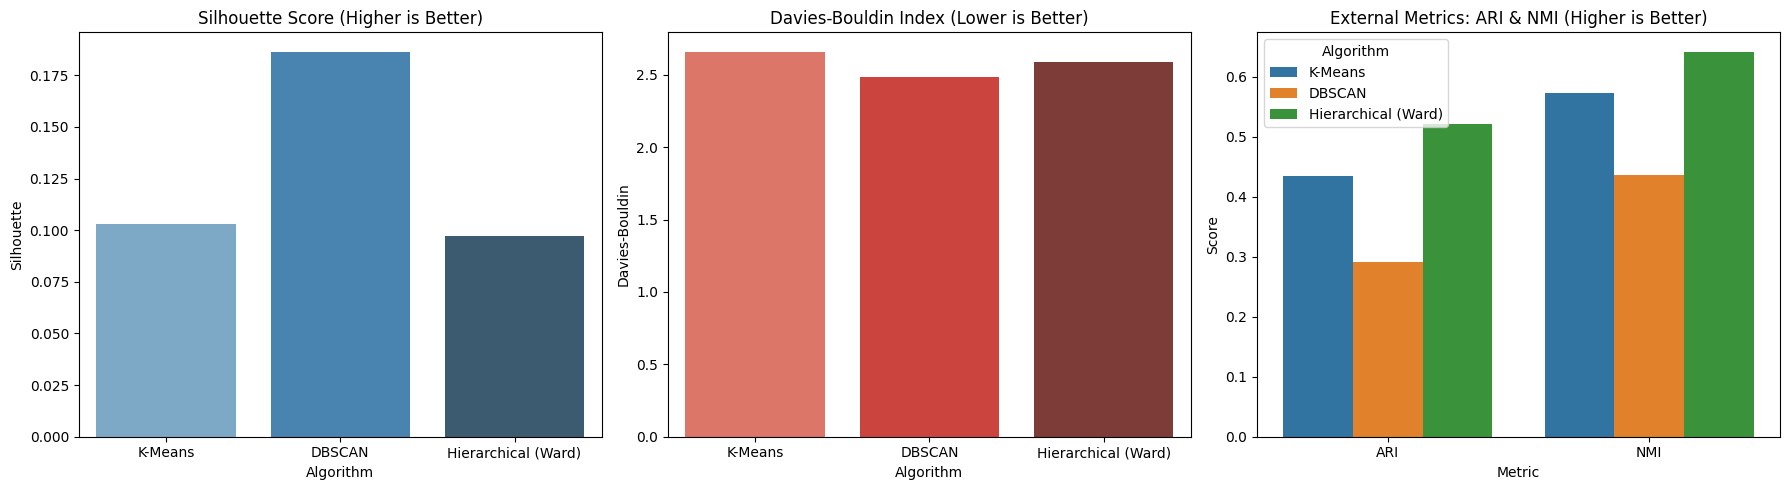

In [10]:

df_melted = df_metrics.melt(id_vars="Algorithm", var_name="Metric", value_name="Score")


fig, axes = plt.subplots(1, 3, figsize=(18, 5))


sns.barplot(data=df_metrics, x="Algorithm", y="Silhouette", ax=axes[0], palette="Blues_d")
axes[0].set_title("Silhouette Score (Higher is Better)")


sns.barplot(data=df_metrics, x="Algorithm", y="Davies-Bouldin", ax=axes[1], palette="Reds_d")
axes[1].set_title("Davies-Bouldin Index (Lower is Better)")


if y_true_labels is not None:
    df_ext = df_melted[df_melted["Metric"].isin(["ARI", "NMI"])]
    sns.barplot(data=df_ext, x="Metric", y="Score", hue="Algorithm", ax=axes[2])
    axes[2].set_title("External Metrics: ARI & NMI (Higher is Better)")
else:
    axes[2].set_title("External Metrics (No Ground Truth Provided)")

plt.tight_layout()
plt.show()